# 1. Import Necessary Libraries

In [1]:
import pandas as pd

#  2.Import Dataset

In [2]:
claimants_data=pd.read_csv('claimants.csv')
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


# 3. Data Understanding

# 3.1 Initial Analysis

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

# 4.Data Prepartion

In [6]:
del claimants_data['CASENUM']

In [7]:
claimants_data.head()

,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0,0.0,1.0,0.0,50.0,34.940
1,1,1.0,0.0,0.0,18.0,0.891
2,1,0.0,1.0,0.0,5.0,0.330
3,0,0.0,1.0,1.0,31.0,0.037
4,1,0.0,1.0,0.0,30.0,0.038


In [8]:
claimants_data.dropna(axis=0,inplace=True)

In [9]:
claimants_data.isna().sum()

ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [10]:
claimants_data.shape

(1096, 6)

# 5.model Building
#### 2 steps process:
   1.Separate Input and Output
       2.Perform some Model Validation Techniques:
    
        *Train-Test Split
        *K-Fold Cross Validation
        *Leave One Out Cross Validation

In [11]:
X = claimants_data.drop('ATTORNEY',axis=1)
Y = claimants_data[['ATTORNEY']]

In [12]:
X.shape,Y.shape

((1096, 5), (1096, 1))

In [13]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.20,random_state=123,shuffle=True)

In [14]:
x_train.shape,y_train.shape

((876, 5), (876, 1))

In [15]:
x_test.shape,y_test.shape

((220, 5), (220, 1))

# 6.Model Training

In [16]:
import warnings
warnings.filterwarnings('ignore')

In [17]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(criterion='gini',max_depth=4) #
dt.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
from sklearn.model_selection import GridSearchCV

grid_search = GridSearchCV(estimator=dt,param_grid={'criterion':['gini','entropy'],
                                                    'max_depth':[3,4,5,6,7,8,9]},cv = 5)
grid_search.fit(X,Y)

grid_search.best_params_

{'criterion': 'gini', 'max_depth': 3}

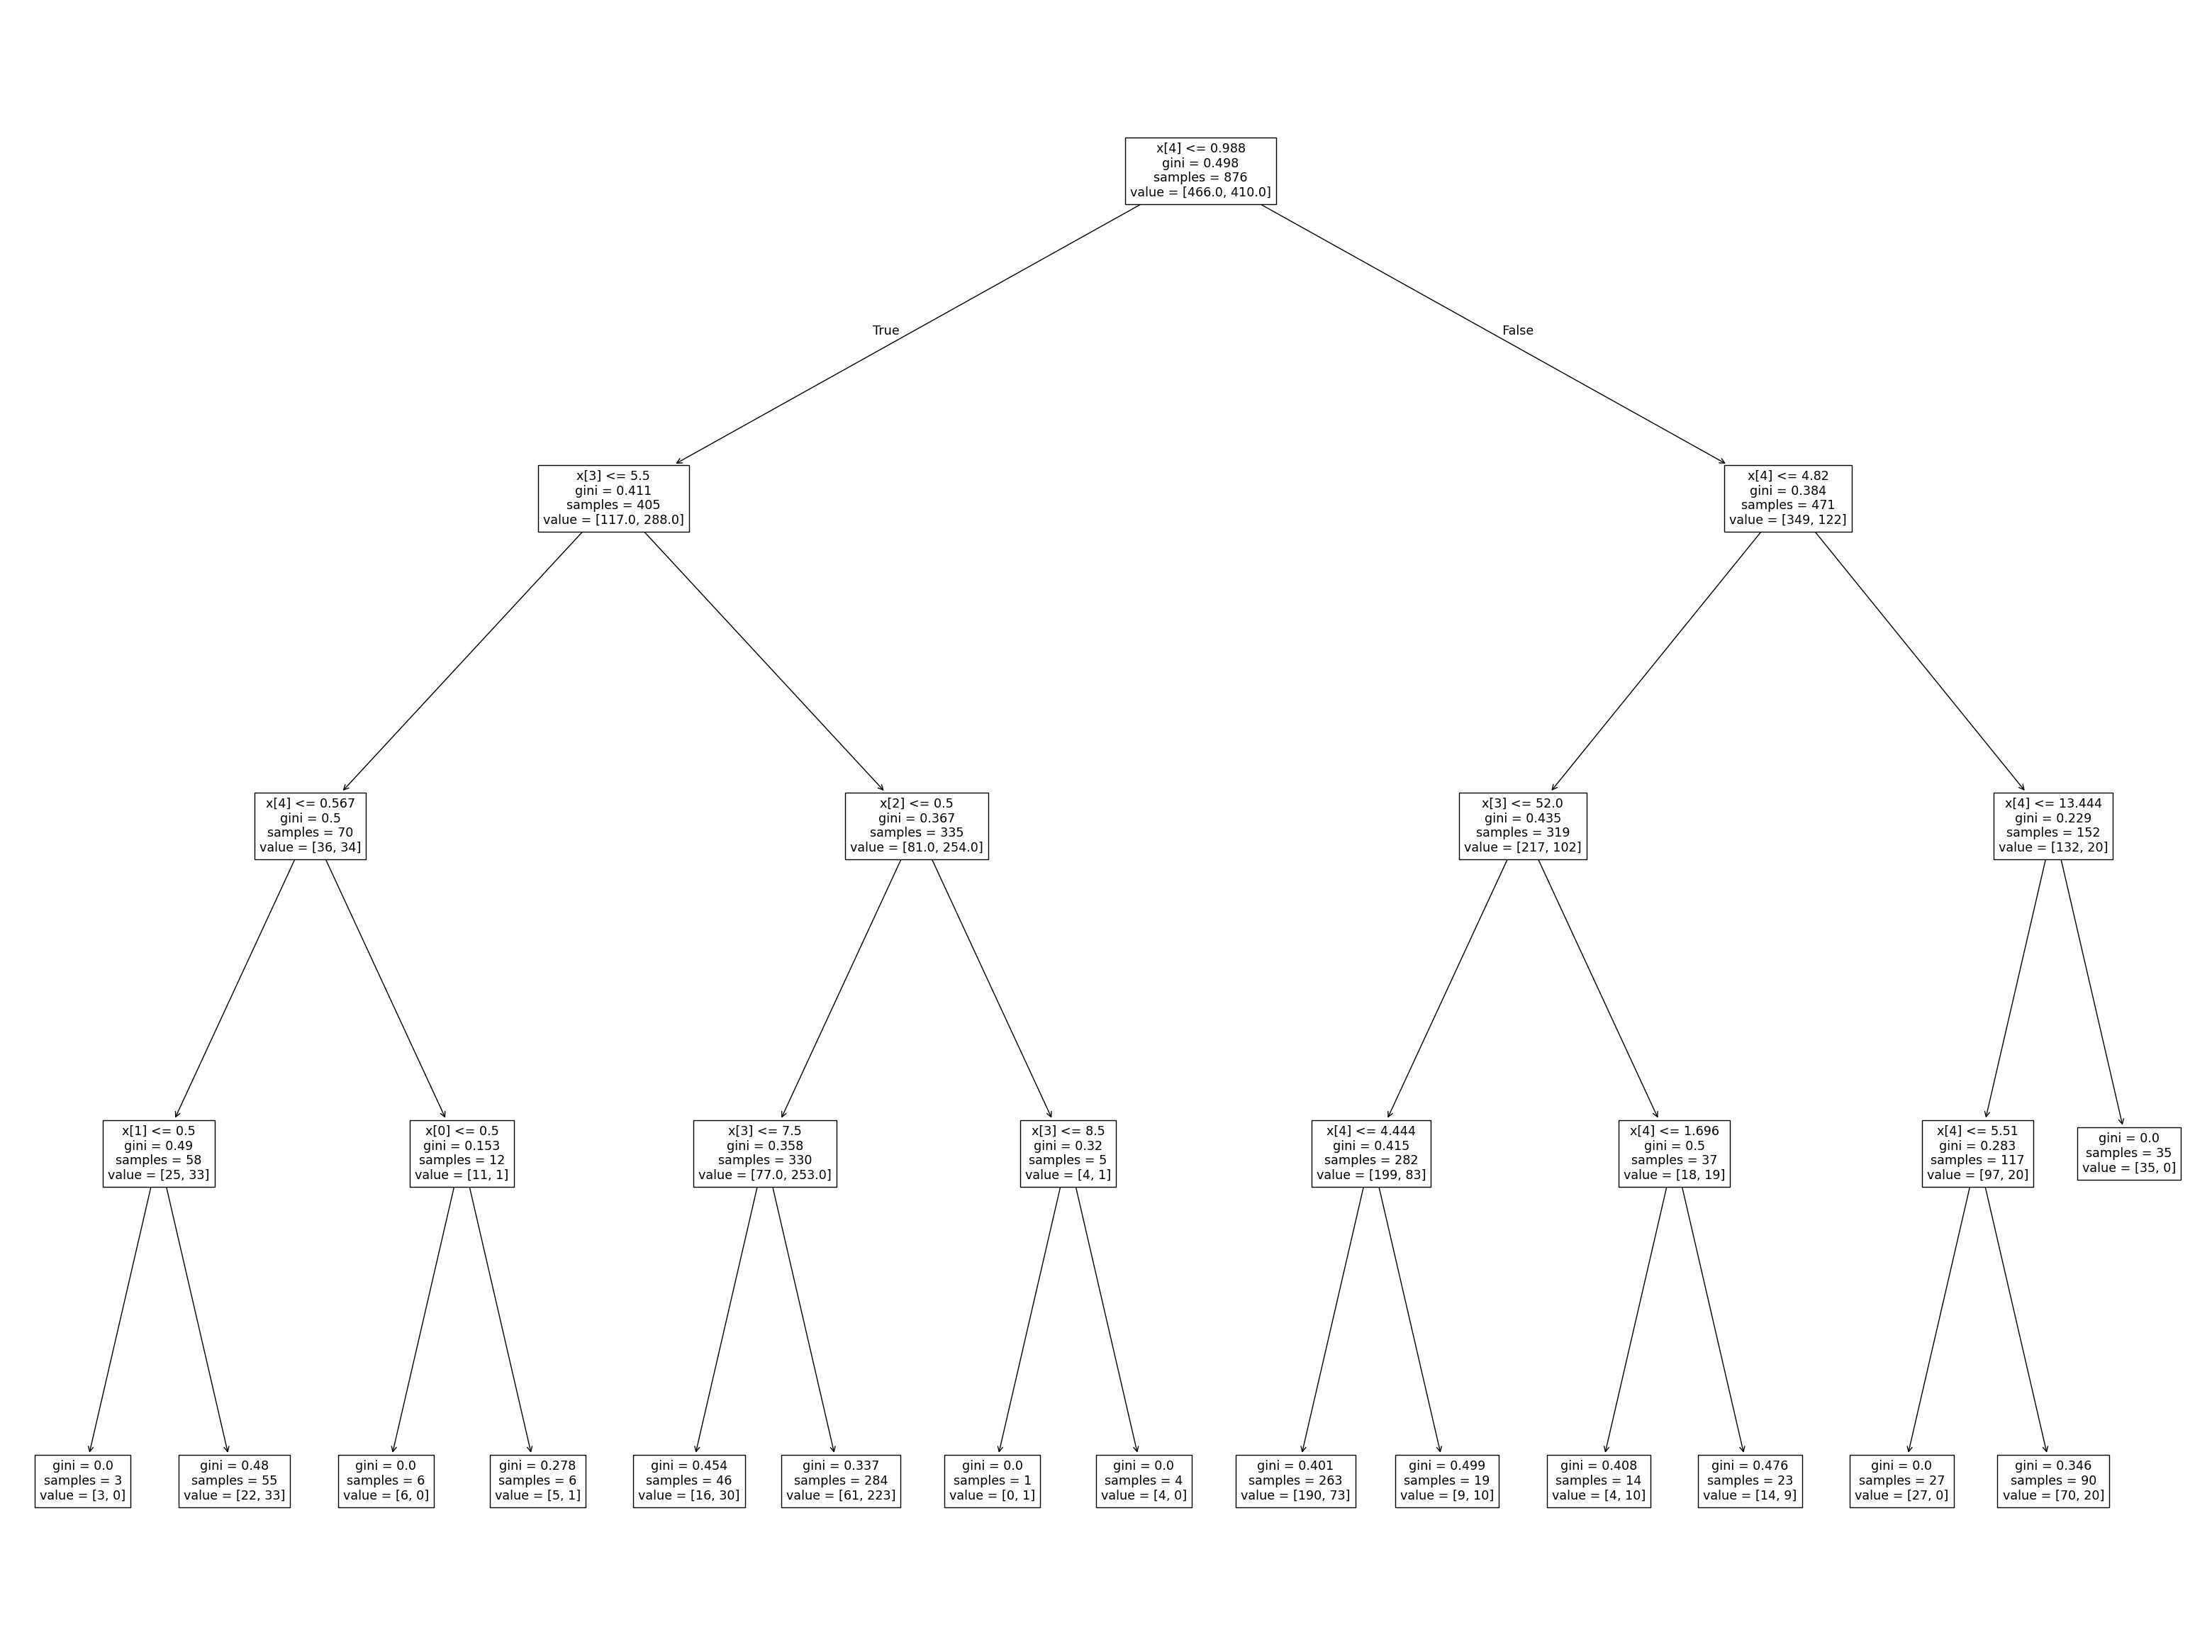

In [19]:
from matplotlib import pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(40,30))
plot_tree(decision_tree = dt,proportion=False)

plt.show()

In [20]:
#plot_tree(decision_tree = dt,proportion=False)

In [21]:
%%time
dt.fit(x_train,y_train)

CPU times: total: 15.6 ms
Wall time: 20.3 ms


,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


# 7.Model Testing

In [22]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_auc_score,roc_curve

In [23]:
y_pred_train=dt.predict(x_train)

In [24]:
accuracy_score(y_train,y_pred_train)

0.7545662100456622

In [25]:
confusion_matrix(y_train,y_pred_train)

array([[354, 112],
       [103, 307]])

In [26]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.77      0.76      0.77       466
           1       0.73      0.75      0.74       410

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



0.7542185700826965


Text(0, 0.5, 'True Positive Rate')

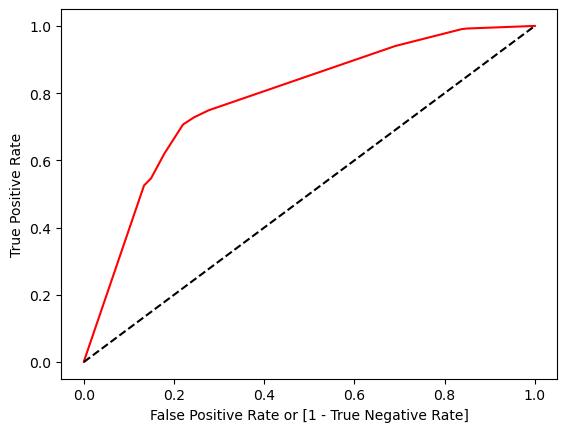

In [27]:
from sklearn.metrics import roc_curve,roc_auc_score
fpr, tpr, thresholds = roc_curve(Y,dt.predict_proba(X)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)


import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color = 'red', label = 'DT model(area =%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

#  8.Test Accuracy

In [28]:
y_pred_test=dt.predict(x_test)

In [29]:
accuracy_score(y_test,y_pred_test)

0.6954545454545454

[[83 29]
 [38 70]]
              precision    recall  f1-score   support

           0       0.69      0.74      0.71       112
           1       0.71      0.65      0.68       108

    accuracy                           0.70       220
   macro avg       0.70      0.69      0.69       220
weighted avg       0.70      0.70      0.69       220

0.6946097883597885


Text(0, 0.5, 'True Positive Rate')

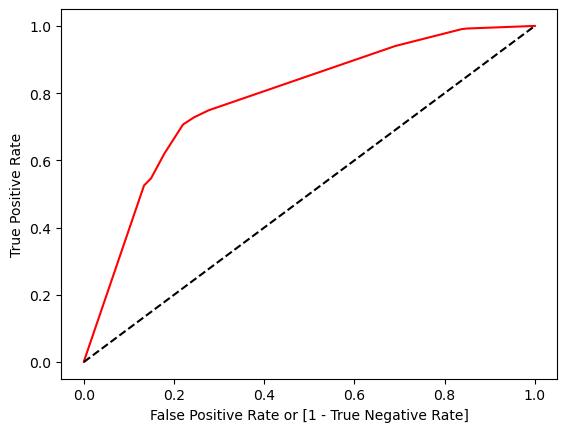

In [30]:
cm = confusion_matrix(y_test,y_pred_test)
print(cm)

print(classification_report(y_test,y_pred_test))

from sklearn.metrics import roc_curve,roc_auc_score
fpr, tpr, thresholds = roc_curve(Y,dt.predict_proba(X)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)


import matplotlib.pyplot as plt
plt.plot(fpr, tpr, color = 'red', label = 'DT model(area =%0.2f)'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')